# Egoístas y generosos maquillan el impacto de sus decisiones

**7 puntos para ti o 5. Lo que recibe otra persona no está claro: entre 1 y 3 puntos con la primera opción, entre 3 y 5 con la segunda. ¿Cuánto mejor es, para el otro, la opción generosa?** Depende de quién responda.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Vollberg y Gross (2026). *Selfish and prosocial individuals both distort their actions’ impact, but selfish distortions can be more contagious*. **Nature Human Behaviour**.
**DOI:** [10.1038/s41562-026-02585-3](https://doi.org/10.1038/s41562-026-02585-3)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-10-01-egoistas-y-prosociales-distorsionan-su-impacto/notebook.ipynb)

**Video:** Pendiente

## El juego

En 9 experimentos en línea, preregistrados (los autores dejaron por escrito sus hipótesis y análisis antes de recoger los datos), 8.769 adultos (la mayoría residentes en EE. UU.) hicieron de **Decisores**. Su pago estaba claro: 7 puntos con la opción egoísta, 5 con la generosa. Lo que recibía otra persona (el **Receptor**) solo se conocía como un rango: 1–3 puntos con la egoísta, 3–5 con la generosa. Después de elegir, cada quien estimaba cuántos puntos recibía el Receptor con cada opción, y cobraba un extra si acertaba.

Si nadie distorsiona, las estimaciones caen en el punto medio de cada rango (2 y 4): la opción generosa le da al otro 2 puntos más. Empecemos por el Experimento 1a: 981 personas. 292 eligieron la opción egoísta y 375 la generosa; otras 314 jugaron una versión de control sin dilema, donde la opción de 7 puntos también era la mejor para el otro.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TIPO_HIST = 'egoista'                 # 'egoista' o 'prosocial': a quién mira el histograma final
CONDICION_INFLUENCER = 'egoista_infla_egoista_rebaja_prosocial'  # condición del Exp 6 que se compara...
REFERENCIA_INFLUENCER = 'sin_distorsion'                         # ...contra esta ('control_rebaja_ambas', 'prosocial_infla_ambas')
FUENTE = 'Fuente: Vollberg y Gross (2026), Nature Human Behaviour | Datos: OSF, doi:10.17605/OSF.IO/VG7N8'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_VIOLETA = '#7C3AED'
COLOR_CONTEXTO = '#BBBBBB'

import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-10-01-egoistas-y-prosociales-distorsionan-su-impacto'
ARCHIVOS = ['exp1a_estimaciones.csv', 'exp6_seguidores.csv',
            'resumen_experimentos.csv', 'tipos_distorsion_exp1ab.csv']
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
for a in ARCHIVOS:
    if not os.path.exists(f'datos/{a}'):
        urllib.request.urlretrieve(f'{BASE}/datos/{a}', f'datos/{a}')

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Números en formato español: coma decimal, punto de miles
def es(x):
    s = str(x)
    s = re.sub(r'(?<=\d)\.(?=\d)', ',', s)
    s = re.sub(r'(\d)e\+?(-?)0*(\d+)', r'\1×10^\2\3', s)
    return s.replace('_', '.').replace('-', '−')

def pr(*a):
    print(*[es(x) for x in a])

COMA = FuncFormatter(lambda v, _: es(f'{v:g}'))

d1 = pd.read_csv('datos/exp1a_estimaciones.csv')       # Exp 1a: 1 fila por Decisor
d6 = pd.read_csv('datos/exp6_seguidores.csv')          # Exp 6: 1 fila por seguidor
resumen = pd.read_csv('datos/resumen_experimentos.csv')  # brecha por experimento (diferencias crudas)
tipos = pd.read_csv('datos/tipos_distorsion_exp1ab.csv') # patrones de distorsión, Exp 1a + 1b

# Estimaciones = desviación (en puntos del Receptor) respecto al punto medio del rango.
# diferencia_percibida = generosa − egoísta: negativa = 'las opciones se parecen más de lo que son'
pr(f'Exp 1a: {len(d1):_} Decisores →', d1.groupby('tipo_decisor').size().to_dict())
pr(f'Exp 6: {len(d6):_} seguidores en {d6.condicion_influencer.nunique()} condiciones')
pr(f'Resumen: {resumen.experimento.size} experimentos, N total = {resumen.n.sum():_}')

Exp 1a: 981 Decisores → {'egoista': 292, 'neutral': 314, 'prosocial': 375}
Exp 6: 849 seguidores en 4 condiciones
Resumen: 9 experimentos, N total = 8.769


Aquí está.

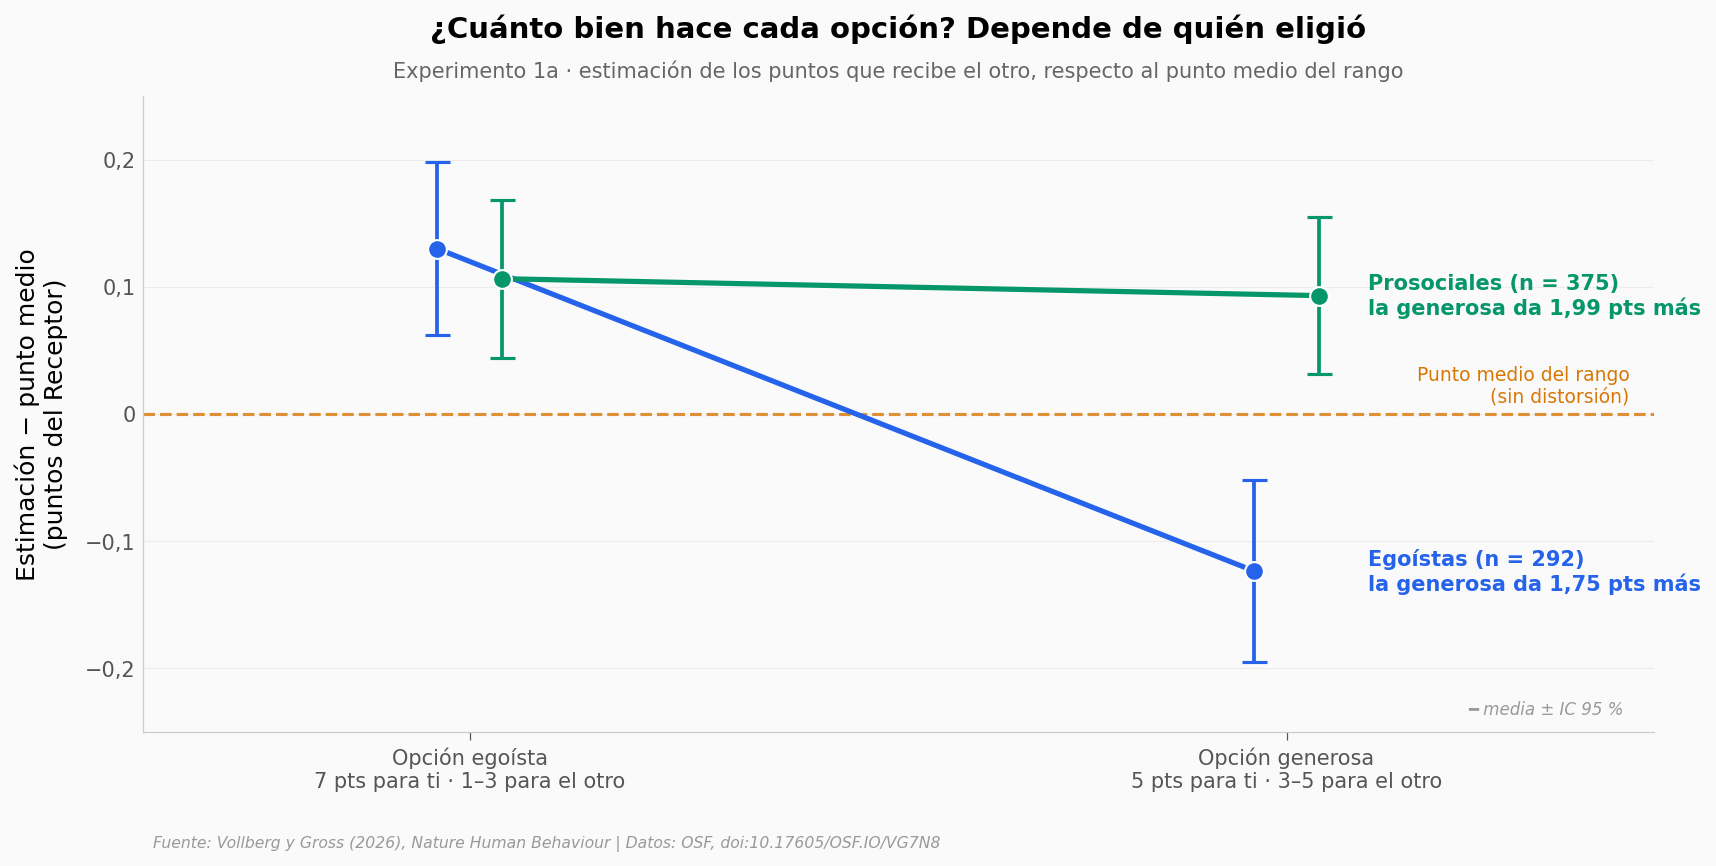

(neutrales: versión de control, sin opción egoísta; sus columnas son opción de 7 y de 5 puntos)
   egoístas (n = 292): opción de 7 pts +0,13 (p = 0,00022) | opción de 5 pts −0,12 (p = 0,00079) | diferencia −0,254 (p = 3,1×10^−10)
prosociales (n = 375): opción de 7 pts +0,11 (p = 0,00085) | opción de 5 pts +0,09 (p = 0,0033) | diferencia −0,013 (p = 0,69)
  neutrales (n = 314): opción de 7 pts −0,03 (p = 0,32) | opción de 5 pts −0,08 (p = 0,0099) | diferencia −0,046 (p = 0,2)
b prosociales − egoístas = 0,24 (IC 95 % 0,14–0,34; t = 4,79)
b neutrales − egoístas = 0,21 (IC 95 % 0,11–0,31; t = 3,98)
Cohen d (prosociales vs egoístas) = 0,37
Shapiro (egoístas) p = 3,6×10^−19 → no normal; Mann‑Whitney p = 0,00034


In [2]:
def ic95(x):
    x = np.asarray(x, dtype=float)
    m, se = x.mean(), x.std(ddof=1) / np.sqrt(len(x))
    t = stats.t.ppf(0.975, len(x) - 1)
    return m, m - t * se, m + t * se

principal = d1[d1.configuracion == 'principal']
grupos = [('egoista', 'Egoístas', COLOR_DATOS, -0.04),
          ('prosocial', 'Prosociales', COLOR_SECUNDARIO, 0.04)]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axhline(0, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(1.42, 0.006, 'Punto medio del rango\n(sin distorsión)', fontsize=9, color=COLOR_REFERENCIA,
        ha='right', va='bottom')
for tipo, nombre, color, dx in grupos:
    sub = principal[principal.tipo_decisor == tipo]
    ys, los, his = zip(*[ic95(sub[c]) for c in ['est_opcion_automax_pts', 'est_opcion_costosa_pts']])
    xs = np.array([0, 1]) + dx
    ax.plot(xs, ys, color=color, linewidth=2.5, zorder=4)
    ax.errorbar(xs, ys, yerr=[np.array(ys) - los, np.array(his) - ys], fmt='o', color=color,
                markersize=9, capsize=6, capthick=1.5, markeredgecolor='white', zorder=5)
    dif = 2 + sub.diferencia_percibida_pts.mean()
    ax.text(1.1, ys[1], f'{nombre} (n = {len(sub)})\nla generosa da ' + es(f'{dif:.2f}') + ' pts más',
            fontsize=10, color=color, fontweight='bold', va='center')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Opción egoísta\n7 pts para ti · 1–3 para el otro',
                    'Opción generosa\n5 pts para ti · 3–5 para el otro'], fontsize=10)
ax.set_xlim(-0.4, 1.45)
ax.set_ylim(-0.25, 0.25)
ax.yaxis.set_major_formatter(COMA)
ax.set_ylabel('Estimación − punto medio\n(puntos del Receptor)')
ax.set_title('¿Cuánto bien hace cada opción? Depende de quién eligió', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Experimento 1a · estimación de los puntos que recibe el otro, respecto al punto medio del rango',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± IC 95 %', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_estimaciones_exp1a.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Números: medias por celda, réplica del modelo del paper (lm diferencia ~ tipo, ref. egoístas) ---
plural = {'egoista': 'egoístas', 'prosocial': 'prosociales', 'neutral': 'neutrales'}
pv = lambda v: stats.ttest_1samp(v, 0).pvalue
pr('(neutrales: versión de control, sin opción egoísta; sus columnas son opción de 7 y de 5 puntos)')
for tipo in ['egoista', 'prosocial', 'neutral']:
    sub = d1[d1.tipo_decisor == tipo]
    a, c, dd = sub.est_opcion_automax_pts, sub.est_opcion_costosa_pts, sub.diferencia_percibida_pts
    pr(f'{plural[tipo]:>11} (n = {len(sub)}): opción de 7 pts {a.mean():+.2f} (p = {pv(a):.2g})'
       f' | opción de 5 pts {c.mean():+.2f} (p = {pv(c):.2g}) | diferencia {dd.mean():+.3f} (p = {pv(dd):.2g})')

X = pd.get_dummies(d1.tipo_decisor)[['neutral', 'prosocial']].astype(float)
X.insert(0, 'intercepto', 1.0)
y = d1.diferencia_percibida_pts.values
b, *_ = np.linalg.lstsq(X.values, y, rcond=None)
res = y - X.values @ b
gl = len(y) - X.shape[1]
se = np.sqrt(np.diag(res @ res / gl * np.linalg.inv(X.values.T @ X.values)))
tc = stats.t.ppf(0.975, gl)
for i, nom in [(2, 'prosociales − egoístas'), (1, 'neutrales − egoístas')]:
    pr(f'b {nom} = {b[i]:.2f} (IC 95 % {b[i]-tc*se[i]:.2f}–{b[i]+tc*se[i]:.2f}; t = {b[i]/se[i]:.2f})')

ego = d1[d1.tipo_decisor == 'egoista'].diferencia_percibida_pts
pro = d1[d1.tipo_decisor == 'prosocial'].diferencia_percibida_pts
sp = np.sqrt(((len(ego)-1)*ego.var() + (len(pro)-1)*pro.var()) / (len(ego)+len(pro)-2))
pr(f'Cohen d (prosociales vs egoístas) = {(pro.mean()-ego.mean())/sp:.2f}')
pr(f'Shapiro (egoístas) p = {stats.shapiro(ego).pvalue:.1e} → no normal; Mann‑Whitney p = {stats.mannwhitneyu(pro, ego).pvalue:.5f}')

Quienes eligieron la opción egoísta, en promedio, la inflaron (+0,13 puntos sobre el punto medio) y rebajaron la generosa (−0,12). Resultado: para ellos la opción generosa le daba al Receptor 1,75 puntos más, no 2. Contra los prosociales, la brecha en esa diferencia percibida es b = 0,24 (IC 95 % 0,14–0,34), la misma cifra que reporta el paper. Es un efecto pequeño: d = 0,37.

Los prosociales también se movieron, pero distinto: inflaron las dos opciones (+0,11 la egoísta, +0,09 la generosa), así que su diferencia percibida queda en −0,01, prácticamente intacta. Comparados con los egoístas, dejan su opción relativamente mejor parada. Según el paper, también agrandan lo que sacrifican al elegirla, aunque eso de forma menos consistente: en el Exp 1c, por ejemplo, su exageración de la opción generosa no se replicó. Y en la versión de control sin dilema, los 314 neutrales dejan la diferencia en −0,05 (p = 0,20): sin distorsión clara.

Ojo con la causalidad: nadie asignó quién sería egoísta, cada persona eligió. Esto es una asociación entre elegir y estimar, no una prueba de que elegir lo egoísta *cause* la distorsión.

## ¿Se repite?

Los autores repitieron el juego con variaciones: sin pago por acertar, explicando con total transparencia cómo se sorteaba el pago del otro (Exp 1c), estimando *antes* de elegir, con la opción *impuesta*, o añadiendo una apuesta propia entre un rango ambiguo y su punto medio seguro (Exp 4). Veamos la brecha prosociales − egoístas en cada uno.

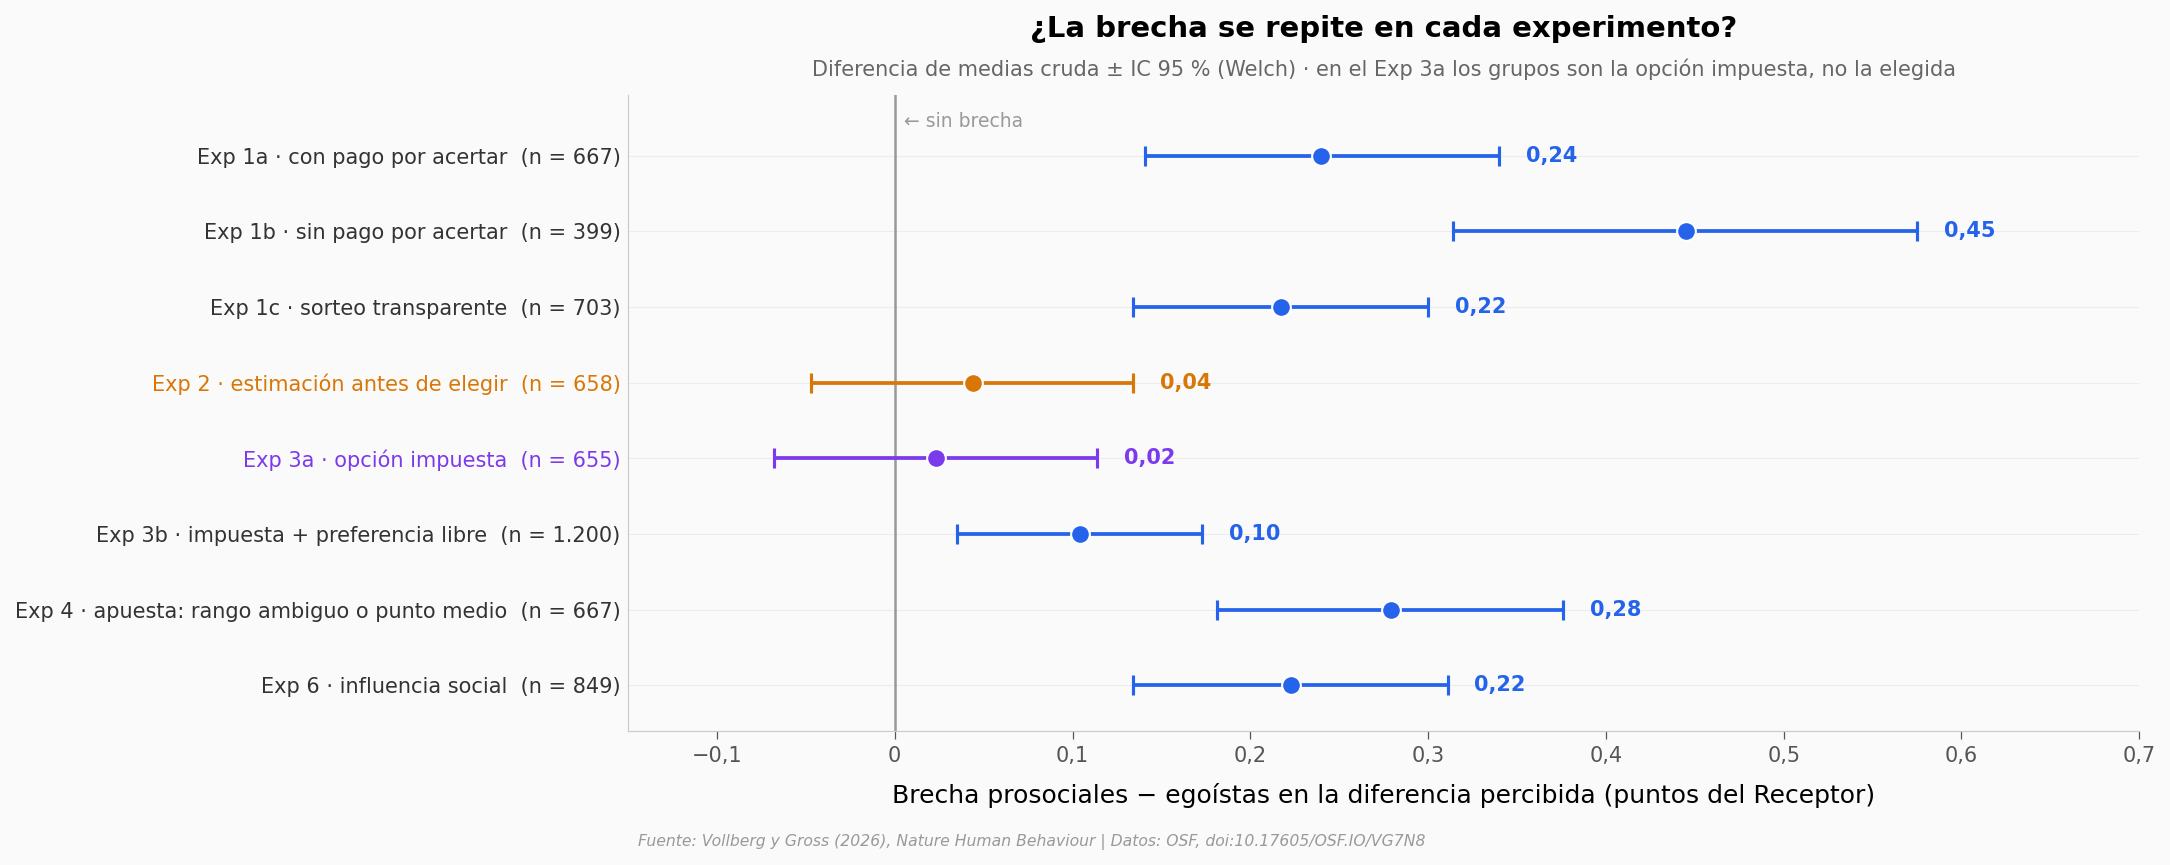

Exp 1a: egoístas −0,25 | prosociales −0,01 | brecha 0,24 (IC 0,14 a 0,34)
Exp 1b: egoístas −0,37 | prosociales +0,08 | brecha 0,45 (IC 0,31 a 0,57)
Exp 1c: egoístas −0,28 | prosociales −0,07 | brecha 0,22 (IC 0,13 a 0,30)
Exp  2: egoístas −0,15 | prosociales −0,11 | brecha 0,04 (IC −0,05 a 0,13)
Exp 3a: egoístas −0,13 | prosociales −0,10 | brecha 0,02 (IC −0,07 a 0,11)
Exp 3b: egoístas −0,17 | prosociales −0,06 | brecha 0,10 (IC 0,04 a 0,17)
Exp  4: egoístas −0,28 | prosociales +0,00 | brecha 0,28 (IC 0,18 a 0,38)
Exp  6: egoístas −0,34 | prosociales −0,12 | brecha 0,22 (IC 0,13 a 0,31)


In [3]:
r = resumen.dropna(subset=['brecha_prosocial_menos_egoista']).reset_index(drop=True)
color_de = {'2': COLOR_REFERENCIA, '3a': COLOR_VIOLETA}
ypos = np.arange(len(r))[::-1]

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axvline(0, color='#999999', linewidth=1.2)
for yv, (_, f) in zip(ypos, r.iterrows()):
    c = color_de.get(f.experimento, COLOR_DATOS)
    ax.errorbar(f.brecha_prosocial_menos_egoista, yv,
                xerr=[[f.brecha_prosocial_menos_egoista - f.ic95_lo], [f.ic95_hi - f.brecha_prosocial_menos_egoista]],
                fmt='o', color=c, markersize=9, capsize=5, capthick=1.5, markeredgecolor='white', zorder=5)
    ax.text(f.ic95_hi + 0.015, yv, es(f'{f.brecha_prosocial_menos_egoista:.2f}'), fontsize=10,
            color=c, fontweight='bold', va='center')
etiquetas = [f'Exp {f.experimento} · {f.descripcion.replace("ANTES", "antes").replace("sin incentivo", "sin pago por acertar").replace("incentivado", "con pago por acertar").replace("elección forzada", "opción impuesta").replace("aleatoriedad explícita", "sorteo transparente").replace("preferencia por ambigüedad", "apuesta: rango ambiguo o punto medio").replace("forzada + preferencia libre", "impuesta + preferencia libre")}  (n = ' + es(f'{int(f.n_egoista + f.n_prosocial):_}') + ')'
             for _, f in r.iterrows()]
ax.set_yticks(ypos)
ax.set_yticklabels(etiquetas, fontsize=10)
for tick, (_, f) in zip(ax.get_yticklabels(), r.iterrows()):
    tick.set_color(color_de.get(f.experimento, '#333333'))
ax.set_xlim(-0.15, 0.7)
ax.xaxis.set_major_formatter(COMA)
ax.set_xlabel('Brecha prosociales − egoístas en la diferencia percibida (puntos del Receptor)')
ax.text(0.005, ypos[0] + 0.45, '← sin brecha', fontsize=9, color='#999999', ha='left', va='center')
ax.set_ylim(ypos[-1] - 0.6, ypos[0] + 0.8)
ax.set_title('¿La brecha se repite en cada experimento?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Diferencia de medias cruda ± IC 95 % (Welch) · en el Exp 3a los grupos son la opción impuesta, no la elegida',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/brecha_por_experimento.png', dpi=200, bbox_inches='tight')
plt.show()

for _, f in r.iterrows():
    pr(f'Exp {f.experimento:>2}: egoístas {f.dif_media_egoista:+.2f} | prosociales {f.dif_media_prosocial:+.2f}'
       f' | brecha {f.brecha_prosocial_menos_egoista:.2f} (IC {f.ic95_lo:.2f} a {f.ic95_hi:.2f})')

En las otras 6 versiones, la brecha es positiva y su IC no toca el cero: va de 0,10 (Exp 3b) a 0,45 (Exp 1b, sin pago por acertar). Dos experimentos se salen, y los dos tienen sentido:

- **Estimar antes de elegir (Exp 2):** la brecha se encoge a 0,04 (IC −0,05 a 0,13). El paper reporta distorsiones en ese experimento con otros análisis, pero esta comparación concreta no se replica.
- **Opción impuesta (Exp 3a):** 0,02 (IC −0,07 a 0,11). Si la distorsión fuera pura justificación de lo que te tocó, los grupos se separarían según la opción impuesta. No se separan, aunque ambos siguen viendo las opciones más parecidas (−0,13 y −0,10). Eso es consistente con que la distorsión refleje preferencias, no solo excusas.

## ¿Se contagia?

En el Experimento 6, 849 personas vieron, antes de elegir, las estimaciones de un participante anterior (el **Influencer**). La distorsión del Influencer se asignó al azar: ninguna, rebaja ambas opciones (control), infla ambas (el patrón prosocial) o infla la egoísta y rebaja la generosa. Como aquí sí hay asignación aleatoria, podemos hablar de efecto.

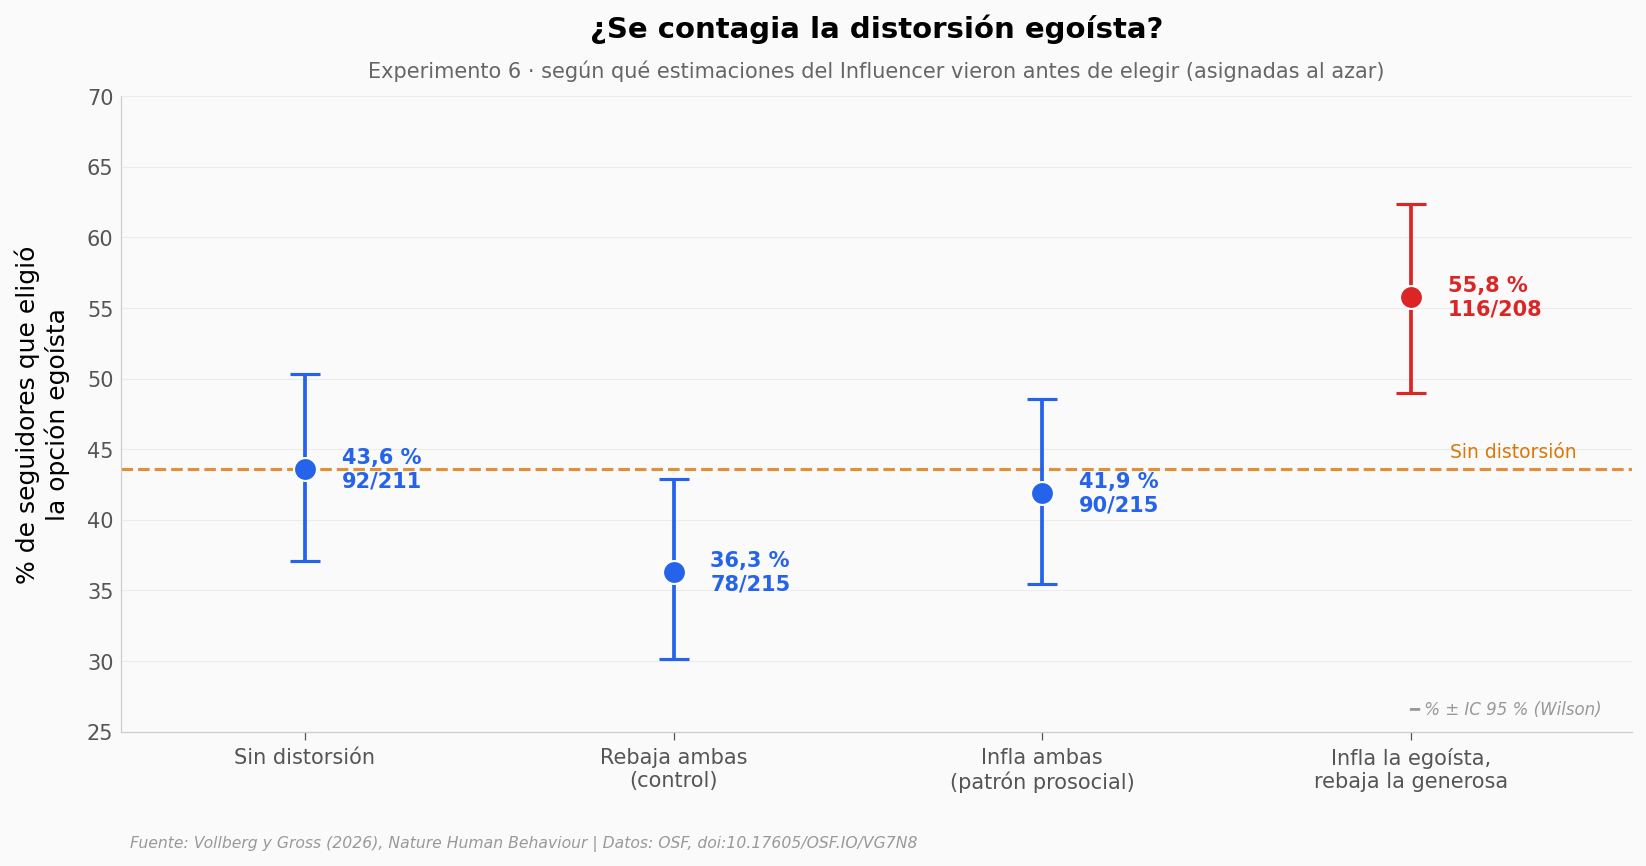

Infla la egoísta, rebaja la generosa vs Sin distorsión: 55,8 % vs 43,6 % → +12,2 puntos porcentuales
b = 0,49 (IC 95 % 0,10–0,88; z = 2,48; p = 0,013) · razón de momios = 1,63 · Cohen h = 0,24
                      Sin distorsión: estiman egoísta +0,085 | generosa −0,064 | copian el patrón egoísta exacto 2,4 %
              Rebaja ambas (control): estiman egoísta +0,016 | generosa −0,132 | copian el patrón egoísta exacto 4,2 %
      Infla ambas (patrón prosocial): estiman egoísta +0,164 | generosa +0,013 | copian el patrón egoísta exacto 3,7 %
Infla la egoísta, rebaja la generosa: estiman egoísta +0,279 | generosa −0,146 | copian el patrón egoísta exacto 11,1 %
Patrón prosocial vs sin distorsión: 90/215 vs 92/211 → p = 0,72, Cohen h = −0,04
Estimación de la opción egoísta, condición egoísta vs sin distorsión (n = 208 y 211): Cohen d = 0,39, Mann‑Whitney p = 0,0003
Copian el patrón egoísta exacto: 23/208 vs 5/211 → Fisher p = 0,0003


In [4]:
orden = [('sin_distorsion', 'Sin distorsión'),
         ('control_rebaja_ambas', 'Rebaja ambas\n(control)'),
         ('prosocial_infla_ambas', 'Infla ambas\n(patrón prosocial)'),
         ('egoista_infla_egoista_rebaja_prosocial', 'Infla la egoísta,\nrebaja la generosa')]

def wilson(k, n, z=1.96):
    p = k / n
    centro = (p + z**2 / (2*n)) / (1 + z**2 / n)
    medio = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / (1 + z**2 / n)
    return centro - medio, centro + medio

tabla = d6.groupby('condicion_influencer').eligio_egoista.agg(k='sum', n='size')
p_ref = tabla.loc['sin_distorsion', 'k'] / tabla.loc['sin_distorsion', 'n'] * 100

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axhline(p_ref, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(3.45, p_ref + 0.8, 'Sin distorsión', fontsize=9, color=COLOR_REFERENCIA, ha='right')
for i, (cond, nombre) in enumerate(orden):
    k, n = tabla.loc[cond, 'k'], tabla.loc[cond, 'n']
    lo, hi = wilson(k, n)
    c = COLOR_ALERTA if cond == 'egoista_infla_egoista_rebaja_prosocial' else COLOR_DATOS
    ax.errorbar(i, k/n*100, yerr=[[k/n*100 - lo*100], [hi*100 - k/n*100]], fmt='o', color=c,
                markersize=11, capsize=7, capthick=1.5, markeredgecolor='white', zorder=5)
    ax.text(i + 0.1, k/n*100, es(f'{k/n*100:.1f} %') + f'\n{k}/{n}', fontsize=10, color=c,
            fontweight='bold', va='center')
ax.set_xticks(range(len(orden)))
ax.set_xticklabels([o[1] for o in orden], fontsize=10)
ax.set_xlim(-0.5, 3.6)
ax.set_ylim(25, 70)
ax.set_ylabel('% de seguidores que eligió\nla opción egoísta')
ax.set_title('¿Se contagia la distorsión egoísta?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Experimento 6 · según qué estimaciones del Influencer vieron antes de elegir (asignadas al azar)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ % ± IC 95 % (Wilson)', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/contagio_exp6.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Logit con una sola variable binaria = log de la razón de momios (réplica del glm del paper) ---
k1, n1 = tabla.loc[CONDICION_INFLUENCER, 'k'], tabla.loc[CONDICION_INFLUENCER, 'n']
k0, n0 = tabla.loc[REFERENCIA_INFLUENCER, 'k'], tabla.loc[REFERENCIA_INFLUENCER, 'n']
b6 = np.log((k1/(n1-k1)) / (k0/(n0-k0)))
se6 = np.sqrt(1/k1 + 1/(n1-k1) + 1/k0 + 1/(n0-k0))
z6 = b6 / se6
h = 2*np.arcsin(np.sqrt(k1/n1)) - 2*np.arcsin(np.sqrt(k0/n0))
nombre_cond = {c: nom.replace('\n', ' ') for c, nom in orden}
pr(f'{nombre_cond[CONDICION_INFLUENCER]} vs {nombre_cond[REFERENCIA_INFLUENCER]}: {k1/n1*100:.1f} % vs {k0/n0*100:.1f} %'
   f' → {(k1/n1-k0/n0)*100:+.1f} puntos porcentuales')
pr(f'b = {b6:.2f} (IC 95 % {b6-1.96*se6:.2f}–{b6+1.96*se6:.2f}; z = {z6:.2f}; p = {2*stats.norm.sf(abs(z6)):.3f})'
   f' · razón de momios = {np.exp(b6):.2f} · Cohen h = {h:.2f}')
est = d6.groupby('condicion_influencer')[['est_opcion_egoista_pts', 'est_opcion_prosocial_pts', 'copio_patron_egoista']].mean()
for cond, nombre in orden:
    f = est.loc[cond]
    pr(f'{nombre.replace(chr(10), " "):>36}: estiman egoísta {f.est_opcion_egoista_pts:+.3f} | generosa {f.est_opcion_prosocial_pts:+.3f}'
       f' | copian el patrón egoísta exacto {f.copio_patron_egoista*100:.1f} %')

# --- Comparaciones fijas contra 'sin distorsión' que cita el texto ---
EGO, SIN, PRO = 'egoista_infla_egoista_rebaja_prosocial', 'sin_distorsion', 'prosocial_infla_ambas'
kp, n_p = tabla.loc[PRO, 'k'], tabla.loc[PRO, 'n']
ks, n_s = tabla.loc[SIN, 'k'], tabla.loc[SIN, 'n']
bp = np.log((kp/(n_p-kp)) / (ks/(n_s-ks)))
sep = np.sqrt(1/kp + 1/(n_p-kp) + 1/ks + 1/(n_s-ks))
hp = 2*np.arcsin(np.sqrt(kp/n_p)) - 2*np.arcsin(np.sqrt(ks/n_s))
pr(f'Patrón prosocial vs sin distorsión: {kp}/{n_p} vs {ks}/{n_s} → p = {2*stats.norm.sf(abs(bp/sep)):.2f}, Cohen h = {hp:.2f}')
e1 = d6[d6.condicion_influencer == EGO].est_opcion_egoista_pts
e0 = d6[d6.condicion_influencer == SIN].est_opcion_egoista_pts
sp6 = np.sqrt(((len(e1)-1)*e1.var() + (len(e0)-1)*e0.var()) / (len(e1)+len(e0)-2))
pr(f'Estimación de la opción egoísta, condición egoísta vs sin distorsión (n = {len(e1)} y {len(e0)}):'
   f' Cohen d = {(e1.mean()-e0.mean())/sp6:.2f}, Mann‑Whitney p = {stats.mannwhitneyu(e1, e0).pvalue:.4f}')
c1 = d6[d6.condicion_influencer == EGO].copio_patron_egoista
c0 = d6[d6.condicion_influencer == SIN].copio_patron_egoista
pr(f'Copian el patrón egoísta exacto: {c1.sum()}/{len(c1)} vs {c0.sum()}/{len(c0)} →'
   f' Fisher p = {stats.fisher_exact([[c1.sum(), len(c1)-c1.sum()], [c0.sum(), len(c0)-c0.sum()]])[1]:.4f}')

Ver al Influencer que inflaba la egoísta y rebajaba la generosa subió la elección egoísta de 43,6 % (sin distorsión) a 55,8 %: +12,2 puntos porcentuales (b = 0,49; IC 95 % 0,10–0,88; razón de momios 1,63). El efecto es pequeño (Cohen h = 0,24), pero los datos apuntan a un contagio. El patrón prosocial no empujó la elección en ningún sentido claro: 41,9 %, casi igual que sin distorsión (p = 0,72).

Los seguidores no solo eligieron distinto, también estimaron distinto: en la condición egoísta valoraron la opción egoísta en +0,28 puntos, contra +0,085 sin distorsión (d = 0,39). Pero copiar el patrón completo del Influencer fue raro: 11,1 % en la condición egoísta (23 de 208) frente a 2,4 % sin distorsión (5 de 211).

## ¿Todos los egoístas distorsionan?

Un promedio de −0,25 puede esconder dos mundos: todos un poquito, o unos pocos mucho. Veamos a cada persona.

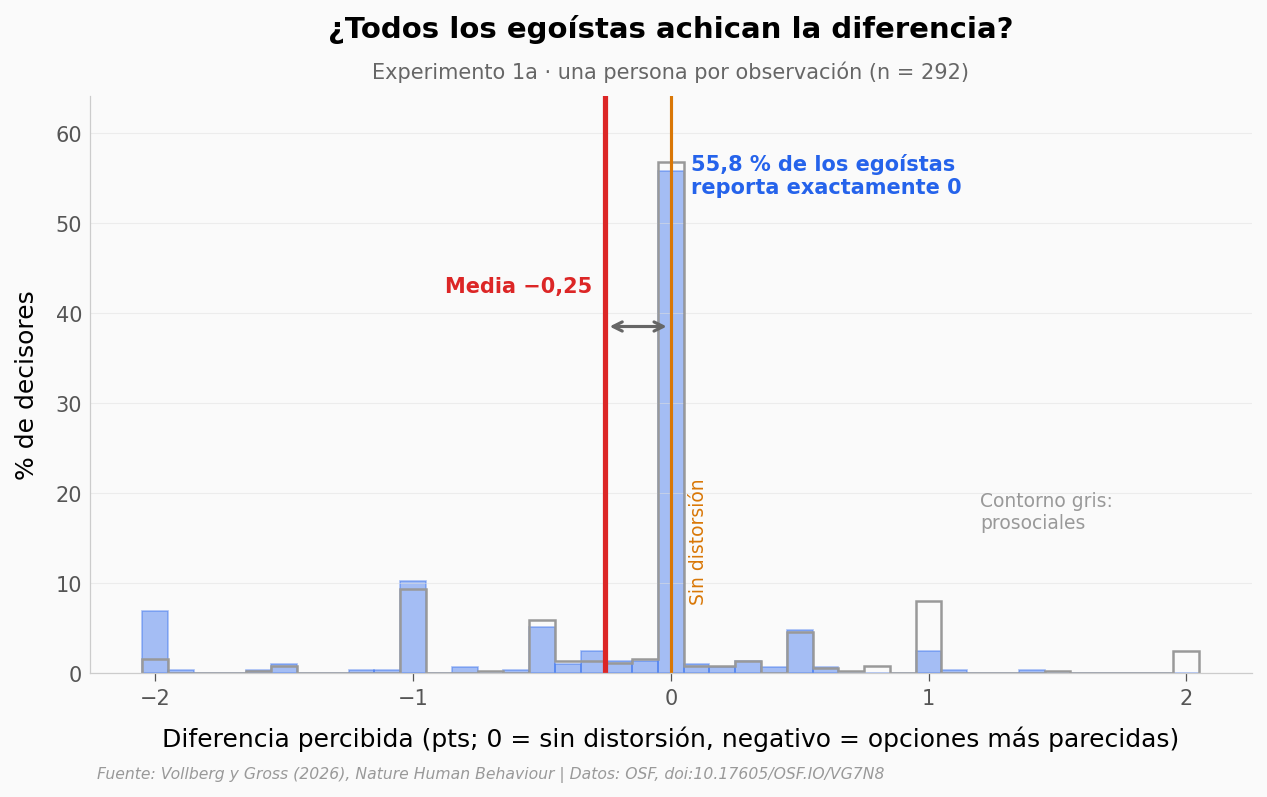

egoístas (n = 292): media −0,254 | mediana 0,0 | IQR −0,5 a 0,0
  < 0: 31,8 % | = 0: 55,8 % | > 0: 12,3 %
Patrón completo (infla egoísta + rebaja generosa), Exp 1a + 1b: 96 de 1.066 = 9,0 % de todos los decisores
  entre egoístas: 68/479 = 14,2 %
  entre prosociales: 28/587 = 4,8 %


In [5]:
nombres = {'egoista': 'egoístas', 'prosocial': 'prosociales'}
otro = 'prosocial' if TIPO_HIST == 'egoista' else 'egoista'
x = principal[principal.tipo_decisor == TIPO_HIST].diferencia_percibida_pts
x_otro = principal[principal.tipo_decisor == otro].diferencia_percibida_pts
media = x.mean()
bins = np.arange(-2.05, 2.1, 0.1)

fig, ax = plt.subplots(figsize=(10, 5))
n, _, _ = ax.hist(x, bins=bins, weights=np.full(len(x), 100/len(x)), color=COLOR_DATOS, alpha=0.4,
                  edgecolor=COLOR_DATOS, linewidth=0.8)
ax.hist(x_otro, bins=bins, weights=np.full(len(x_otro), 100/len(x_otro)), histtype='step',
        color='#999999', linewidth=1.2)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)
ax.axvline(x=0, color=COLOR_REFERENCIA, linewidth=1.5)
ax.axvline(x=media, color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(media, y_max*0.6), xytext=(0, y_max*0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(media - 0.05, y_max*0.66, 'Media ' + es(f'{media:+.2f}'), fontsize=10, color=COLOR_ALERTA,
        fontweight='bold', ha='right')
ax.text(0.08, y_max*0.9, es(f'{(x == 0).mean()*100:.1f} %') + ' de los ' + nombres[TIPO_HIST] + '\nreporta exactamente 0',
        fontsize=10, color=COLOR_DATOS, fontweight='bold', ha='left', va='top')
ax.text(0.07, y_max*0.12, 'Sin distorsión', fontsize=9, color=COLOR_REFERENCIA, ha='left', va='bottom', rotation=90)
ax.text(1.2, y_max*0.25, 'Contorno gris:\n' + nombres[otro], fontsize=9, color='#999999', ha='left')
ax.xaxis.set_major_formatter(COMA)
ax.set_xlabel('Diferencia percibida (pts; 0 = sin distorsión, negativo = opciones más parecidas)')
ax.set_ylabel('% de decisores')
ax.set_title('¿Todos los ' + nombres[TIPO_HIST] + ' achican la diferencia?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Experimento 1a · una persona por observación (n = {len(x)})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_diferencia_percibida.png', dpi=200, bbox_inches='tight')
plt.show()

q1, med, q3 = np.percentile(x, [25, 50, 75])
pr(f'{nombres[TIPO_HIST]} (n = {len(x)}): media {media:+.3f} | mediana {med:.1f} | IQR {q1:.1f} a {q3:.1f}')
pr(f'  < 0: {(x < 0).mean()*100:.1f} % | = 0: {(x == 0).mean()*100:.1f} % | > 0: {(x > 0).mean()*100:.1f} %')
pat = tipos[tipos.patron == 'infla_egoista_rebaja_prosocial']
tot = tipos.groupby('tipo_decisor').n.sum()
pr(f'Patrón completo (infla egoísta + rebaja generosa), Exp 1a + 1b: {pat.n.sum()} de {tot.sum():_}'
   f' = {pat.n.sum()/tot.sum()*100:.1f} % de todos los decisores')
for _, f in pat.iterrows():
    pr(f'  entre {nombres[f.tipo_decisor]}: {f.n}/{tot[f.tipo_decisor]} = {f.n/tot[f.tipo_decisor]*100:.1f} %')

El valor más frecuente es 0: el 55,8 % de los egoístas del Exp 1a reportó exactamente la diferencia del punto medio. Un 31,8 % la achicó y un 12,3 % la agrandó. La mediana es 0; el promedio de −0,25 lo arrastra una minoría que achica mucho. Y el patrón completo (inflar la egoísta y rebajar la generosa) lo produjo apenas el 9,0 % de los decisores de los Exp 1a y 1b (96 de 1.066); entre los egoístas sube a 14,2 %.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| En promedio, los egoístas reportaron las dos opciones como más parecidas que los prosociales | ✅ | Exp 1a: b = 0,24 (IC 95 % 0,14–0,34; t = 4,79), réplica exacta del paper; d = 0,37 (pequeño); Mann-Whitney p = 0,0003 porque la distribución no es normal |
| Los egoístas inflaron su opción y rebajaron la generosa | ✅ | Medias +0,13 y −0,12 puntos frente al punto medio (n = 292; p = 0,0002 y 0,0008); es un promedio, no la conducta típica |
| Los prosociales inflaron las dos opciones | ⚠️ | Exp 1a: +0,11 y +0,09 (n = 375; p = 0,0009 y 0,003), diferencia percibida −0,01. El paper describe parte de la distorsión prosocial como menos consistente: en el Exp 1c su exageración de la opción generosa no se replicó |
| La mayoría de los egoístas no distorsiona la diferencia | ✅ | Exp 1a (n = 292): mediana 0; 55,8 % reporta exactamente 0. El patrón completo (inflar la egoísta y rebajar la generosa) es el 14,2 % de los egoístas de 1a y 1b (68 de 479) |
| La brecha aparece aunque se estime antes de elegir | ⚠️ | Exp 2: brecha 0,04 (IC −0,05 a 0,13), no se replica en esta comparación; el paper reporta distorsiones con otros análisis |
| La distorsión refleja preferencias y no solo justificación | ⚠️ | Consistente con el Exp 3a (opción impuesta: brecha 0,02), pero el paper lo enmarca como "consistente con", no como prueba |
| Ver la distorsión egoísta del Influencer aumentó la elección egoísta | ✅ | Exp 6, asignación aleatoria: 43,6 % → 55,8 % (b = 0,49; IC 95 % 0,10–0,88; n = 419); efecto pequeño (h = 0,24) |
| Esto explica la polarización sobre el impacto social de nuestras acciones | ❌ | La polarización no se midió; los autores plantean que estos datos podrían ayudar a explicarla |

> **Limitaciones:** muestras en línea (Prolific), la mayoría residentes en EE. UU.; los puntos de un juego no son decisiones de la vida real. En el Exp 1a el grupo (egoísta o prosocial) lo elige cada persona: comparación observacional. La brecha por experimento es una diferencia de medias cruda con IC de Welch, no los modelos mixtos del paper (en el Exp 1a coinciden). Las estimaciones van en pasos de 0,1 y se amontonan en 0 (Shapiro p < 10⁻¹⁸). El Exp 5 (juicios de terceros) no entra en este análisis.

## Ahora tú

1. **¿Los prosociales también tienen una minoría que distorsiona fuerte?** Cambia `TIPO_HIST = 'prosocial'` en la celda de configuración y vuelve a correr el histograma.
2. **¿El Influencer egoísta gana también contra el control que rebaja ambas opciones?** Prueba `REFERENCIA_INFLUENCER = 'control_rebaja_ambas'` y vuelve a correr la celda del Experimento 6.
3. **¿Qué patrones de distorsión dominan entre egoístas y prosociales?** La celda de abajo ordena los 9 patrones de los Exp 1a y 1b.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Patrones de distorsión (signo de cada estimación) para TIPO_HIST, Exp 1a + 1b
nombres_patron = {'sin_distorsion': 'sin distorsión',
                  'infla_ambas': 'infla ambas',
                  'rebaja_ambas': 'rebaja ambas',
                  'infla_egoista_rebaja_prosocial': 'infla egoísta, rebaja generosa',
                  'rebaja_egoista_infla_prosocial': 'rebaja egoísta, infla generosa',
                  'solo_infla_egoista': 'solo infla la egoísta',
                  'solo_rebaja_egoista': 'solo rebaja la egoísta',
                  'solo_infla_prosocial': 'solo infla la generosa',
                  'solo_rebaja_prosocial': 'solo rebaja la generosa'}
tab = tipos[tipos.tipo_decisor == TIPO_HIST].sort_values('pct', ascending=False)
pr(f'Patrones entre {nombres[TIPO_HIST]} (n = {tab.n.sum()}):')
for _, f in tab.iterrows():
    pr(f'  {nombres_patron[f.patron]:<32} {f.n:>4}  {f.pct:5.1f} %')

Patrones entre egoístas (n = 479):
  sin distorsión                    161   33,6 %
  rebaja ambas                       82   17,1 %
  infla ambas                        79   16,5 %
  infla egoísta, rebaja generosa     68   14,2 %
  solo rebaja la generosa            37    7,7 %
  solo infla la egoísta              20    4,2 %
  solo rebaja la egoísta             18    3,8 %
  solo infla la generosa              8    1,7 %
  rebaja egoísta, infla generosa      6    1,3 %


## Créditos

- **Paper:** Vollberg y Gross (2026). *Selfish and prosocial individuals both distort their actions’ impact, but selfish distortions can be more contagious*. Nature Human Behaviour. [DOI: 10.1038/s41562-026-02585-3](https://doi.org/10.1038/s41562-026-02585-3)
- **Datos:** datos y código de análisis de los autores en OSF ([10.17605/OSF.IO/VG7N8](https://doi.org/10.17605/OSF.IO/VG7N8)). Los 4 CSV de `datos/` salen del archivo `ImpactDistortions.RData`.
- **Notebook:** [Ciencia a Mordiscos · El Lab](https://github.com/Ciencia-a-Mordiscos/lab) — código bajo licencia del repositorio.

## Fuentes

**Paper**: [Selfish and prosocial individuals both distort their actions’ impact, but selfish distortions can be more contagious](https://doi.org/10.1038/s41562-026-02585-3)  
*Nature Human Behaviour, 2026-10-01 · acceso abierto*

**Datos**: [Selfish and prosocial individuals both distort their actions' impact, but selfish distortions can be more contagious (datos y código de análisis, Vollberg y Gross)](https://doi.org/10.17605/OSF.IO/VG7N8)  
*OSF, 2026-07-21 — datos por participante y código de análisis en R*

*23 afirmaciones del notebook verificadas contra estas fuentes*